## Step 2: Spectral extraction

**Tutorial series:**
- [Step 1: Frame sorting](step1_frame_sorting.ipynb)
- **Step 2: Spectral extraction** ← you are here
- [Step 3: Image reconstruction](step3_image_reconstruction.ipynb)

---

This notebook converts the output of `average_to_h5()` into a **coupling-map FITS file** that `CouplingMapModel` in `mapmodel.py` can consume directly.

### What happens here

```
average_map.h5
  avg_PLcam (map_n, map_n, ny, nx)   ← mean detector image per grid bin
        ↓  extract_to_coupling_map(extractor=box_extractor)
coupling_map.fits
  [0] (map_n, map_n, nfib, nwav)     ← mean spectra per bin
  [1] (map_n, map_n)                 ← nframes per bin
  [3] (map_n, map_n, nfib, nwav)     ← variance
  [4] (map_n, map_n, nfib, nwav)     ← normalized variance
        ↓  CouplingMapModel(mapdata=...)
polynomial model → image reconstruction
```

The **extractor** is a plain Python callable `f(image) → (nfib, nwav)`.  
Here we use simple **box extraction**: sum pixel rows within a fixed window around each fiber trace.

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import matplotlib.pyplot as plt
import h5py

import PLred.specextract as specextract
import PLred.mapmodel as mapmodel

### 1. Load and inspect the averaged H5

In [2]:
averaged_h5 = 'timestamp_matching_output/average_map.h5'

with h5py.File(averaged_h5, 'r') as f:
    avg_plcam = f['avg_PLcam'][:]           # (map_n, map_n, ny, nx)
    nframes   = f['metadata/nframes'][:]    # (map_n, map_n)
    x_mas     = f['metadata/x_mas'][:]      # (map_n,)
    y_mas     = f['metadata/y_mas'][:]      # (map_n,)

map_n, _, ny, nx = avg_plcam.shape
print(f'map_n={map_n},  ny={ny},  nx={nx}')
print(f'x_mas: {x_mas}')
print(f'y_mas: {y_mas}')
print(f'nframes per bin:\n{nframes}')

map_n=5,  ny=412,  nx=20
x_mas: [-12.96  -6.48   0.     6.48  12.96]
y_mas: [-12.96  -6.48   0.     6.48  12.96]
nframes per bin:
[[0 0 2 1 0]
 [0 4 7 2 0]
 [0 4 9 4 1]
 [1 3 4 1 0]
 [0 0 3 2 0]]


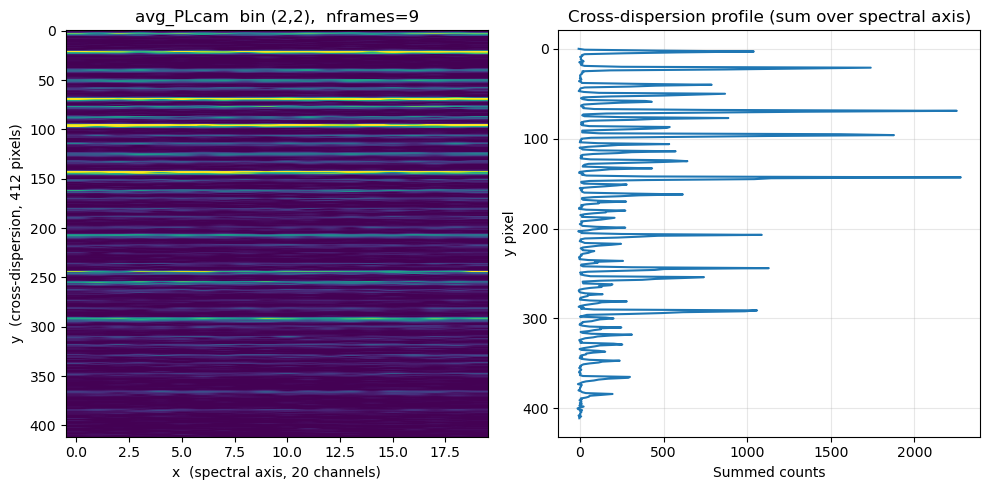

In [3]:
# Visualize the mean PL detector image for the most-populated bin
ix, iy = np.unravel_index(np.argmax(nframes), nframes.shape)
img = avg_plcam[ix, iy]   # (ny=412, nx=20)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Full image
vmax = np.nanpercentile(img, 99)
axes[0].imshow(img, aspect='auto', vmin=0, vmax=vmax, origin='upper', cmap='viridis')
axes[0].set_xlabel('x  (spectral axis, 20 channels)')
axes[0].set_ylabel('y  (cross-dispersion, 412 pixels)')
axes[0].set_title(f'avg_PLcam  bin ({ix},{iy}),  nframes={nframes[ix,iy]}')

# Cross-dispersion profile (collapse spectral axis)
profile = np.nansum(img, axis=1)   # (ny,)
axes[1].plot(profile, np.arange(ny))
axes[1].invert_yaxis()
axes[1].set_xlabel('Summed counts')
axes[1].set_ylabel('y pixel')
axes[1].set_title('Cross-dispersion profile (sum over spectral axis)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Find fiber trace positions

`IRPLred.spec.locate_spectra()` finds fiber peaks iteratively from the cross-dispersion
profile of the detector image — no manual inspection needed.
In a real pipeline the trace positions come from a bright lamp calibration frame
(neon or flat); here we use the brightest science bin directly.

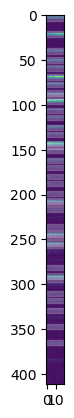

38 fiber traces found at y = [3, 21, 40, 50, 59, 69, 77, 87, 90, 96, 106, 114, 125, 133, 143, 146, 151, 162, 170, 180, 188, 199, 207, 210, 217, 236, 244, 247, 254, 257, 281, 291, 294, 310, 318, 329, 347, 365]


In [5]:
from PLred.IRPLred import spec as irspec

# locate_spectra iteratively finds the brightest remaining peak, masks it, repeats.
# num_spec: number of fibers to find.  width: exclusion half-width around each peak.
# exclude: pixel indices to zero out before searching (e.g. detector edge artefacts).
ylocs = irspec.locate_spectra(avg_plcam[ix, iy], num_spec=38, width=3,
                              plot=True, exclude=[0])

print(f'{len(ylocs)} fiber traces found at y = {sorted(ylocs)}')

### 3. Build a box extractor

`specextract.make_irplred_extractor()` wraps `IRPLred.spec.extract_spec` and returns a
ready-to-use callable `f(image) → (nfib, nwav)`.

`dark=None` here because dark subtraction was already applied in `ingest_to_h5` (Step 1).
Pass `dark=dark_frame` if you need to subtract in this step instead.

Extractor output shape: (38, 20)  (nfib=38, nwav=20)


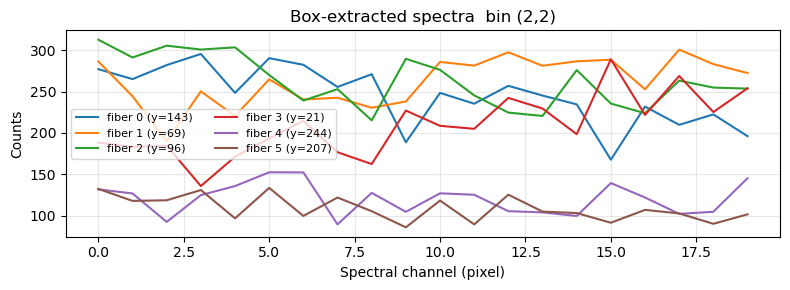

In [6]:
my_extractor = specextract.make_irplred_extractor(ylocs, width=3, dark=None)

# Sanity check on one image
test_spec = my_extractor(avg_plcam[ix, iy])
print(f'Extractor output shape: {test_spec.shape}  (nfib={len(ylocs)}, nwav={nx})')

# Plot a few fiber spectra
fig, ax = plt.subplots(figsize=(8, 3))
for fib_i in range(min(6, len(ylocs))):
    ax.plot(test_spec[fib_i], label=f'fiber {fib_i} (y={ylocs[fib_i]})')
ax.set_xlabel('Spectral channel (pixel)')
ax.set_ylabel('Counts')
ax.set_title(f'Box-extracted spectra  bin ({ix},{iy})')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### For visPLred (visible photonic lantern)

visPLred data requires two extra calibration steps before extraction:
1. **Nonlinearity correction** — per-pixel polynomial model from flat frames  
   (calibrated in `visPLred/tutorials/pre1_nonlinearity_correction.ipynb`)
2. **Optimal extraction** — uses a sparse matrix `A` built from the spectrum model  
   (calibrated in `visPLred/tutorials/pre2_spectrum_model.ipynb`)

`make_visplred_extractor` wires all three steps into the same callable interface:

```python
my_extractor = specextract.make_visplred_extractor(
    A                = A,                       # sparse extraction matrix
    dark             = dark_frame,              # 2D dark array
    nonlin_modelfile = 'nonlin_model.fits',     # from pre1 notebook
)
specextract.extract_to_coupling_map('averaged.h5', my_extractor, 'coupling_map.fits')
```

### 4. Extract spectra for every grid bin

`extract_to_coupling_map()` loops over all `map_n × map_n` bins, applies the extractor,
and writes a FITS file that `CouplingMapModel` can load directly.

**Variance** falls back to a Poisson approximation here (`var = spectra / nframes`) because
this dataset has no bootstrap resamples. If you ran `average_to_h5(..., n_bootstrap=100)`,
the variance would be estimated from the resamples instead.

In [7]:
output_fits = 'timestamp_matching_output/coupling_map.fits'

specextract.extract_to_coupling_map(
    averaged_h5   = averaged_h5,
    extractor     = my_extractor,
    output_fits   = output_fits,
    use_bootstrap = True,    # uses bootstrap resamples if present, Poisson otherwise
    verbose       = True,
)

Loaded timestamp_matching_output/average_map.h5: map_n=5, avg_PLcam shape=(5, 5, 412, 20)
Extractor output shape: nfib=38, nwav=20
Extracting spectra per grid bin...


Extracting: 100%|██████████| 25/25 [00:00<00:00, 6148.92it/s]

Variance estimated via Poisson approximation (spectra / nframes).
Coupling map FITS written to: timestamp_matching_output/coupling_map.fits
  spectra shape : (5, 5, 38, 20)
  valid bins    : 15 / 25


'timestamp_matching_output/coupling_map.fits'

### 5. Inspect the coupling-map FITS

In [8]:
from astropy.io import fits

with fits.open(output_fits) as hdul:
    hdul.info()
    print()
    hdr = hdul[0].header
    print(f"MAP_N = {hdr['MAP_N']},  NFIB = {hdr['NFIB']},  NWAV = {hdr['NWAV']}")
    print(f"XMIN  = {hdr['XMIN']:.2f} mas,  XMAX = {hdr['XMAX']:.2f} mas")
    print()
    data      = hdul[0].data    # (map_n, map_n, nfib, nwav)
    nfr       = hdul[1].data    # (map_n, map_n)
    datavar   = hdul[3].data
    normvar   = hdul[4].data

print('data shape   :', data.shape)
print('nframes shape:', nfr.shape)
print('var shape    :', datavar.shape)
print('normvar shape:', normvar.shape)

Filename: timestamp_matching_output/coupling_map.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  data          1 PrimaryHDU      14   (20, 38, 5, 5)   float32   
  1  nframes       1 ImageHDU         8   (5, 5)   int32   
  2  reserved      1 ImageHDU        10   (20, 38, 5, 5)   float32   
  3  var           1 ImageHDU        10   (20, 38, 5, 5)   float32   
  4  normvar       1 ImageHDU        10   (20, 38, 5, 5)   float32   

MAP_N = 5,  NFIB = 38,  NWAV = 20
XMIN  = -12.96 mas,  XMAX = 12.96 mas

data shape   : (5, 5, 38, 20)
nframes shape: (5, 5)
var shape    : (5, 5, 38, 20)
normvar shape: (5, 5, 38, 20)


### 6. Visualize coupling maps

Each panel below shows the **mean response of one fiber** averaged over all spectral channels,
as a function of the PSF position on the sky grid.

/var/folders/3q/t9m8zt610pjc_x572xlprc000000gn/T/ipykernel_46730/3991739919.py:2: RuntimeWarning: Mean of empty slice
  mean_map = np.nanmean(data, axis=3)   # (map_n, map_n, nfib)


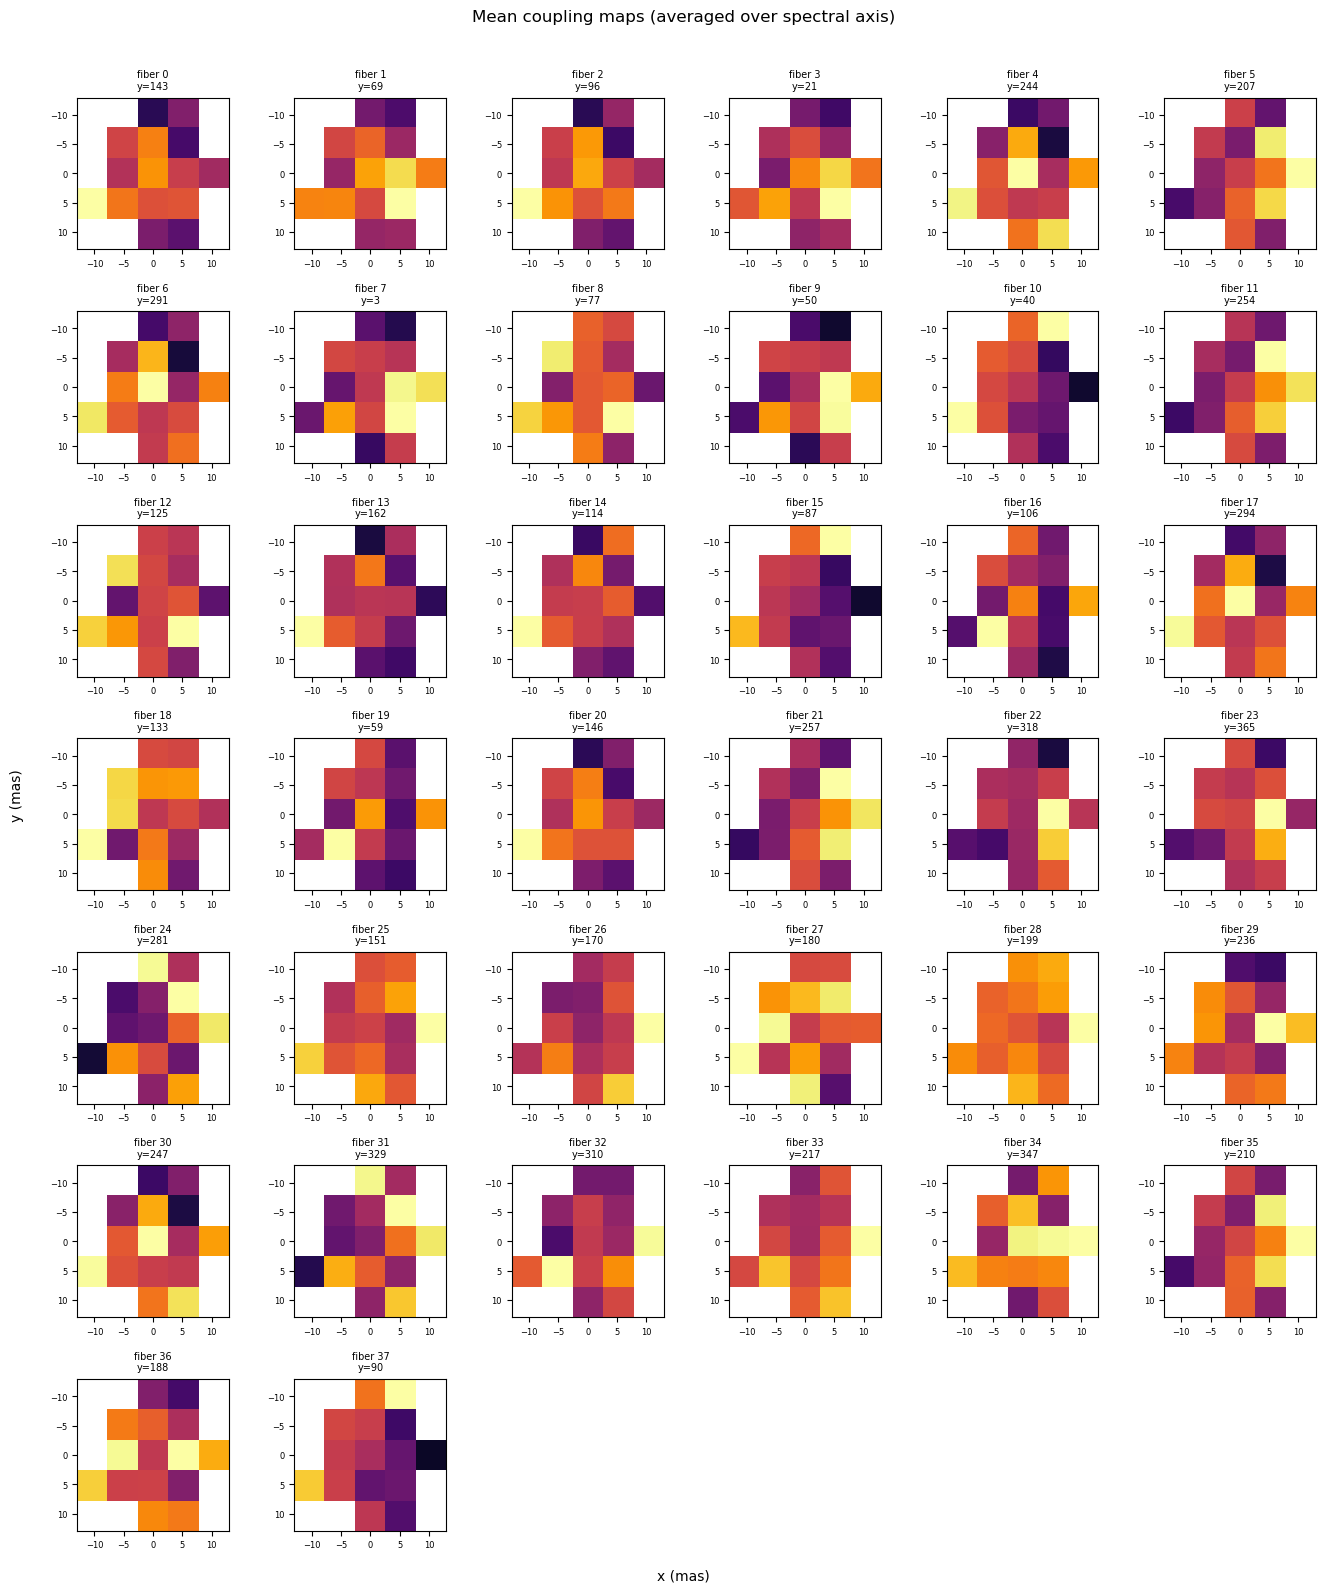

In [9]:
# Mean coupling map per fiber (average over spectral channels)
mean_map = np.nanmean(data, axis=3)   # (map_n, map_n, nfib)

nfib = mean_map.shape[2]
ncols = 6
nrows = int(np.ceil(nfib / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 2.2))
axes = axes.flatten()

extent = [x_mas[0], x_mas[-1], y_mas[-1], y_mas[0]]  # mas

for fib_i in range(nfib):
    ax = axes[fib_i]
    m = mean_map[:, :, fib_i]
    vmax = np.nanpercentile(m, 98)
    ax.imshow(m, extent=extent, origin='upper', cmap='inferno',
              vmin=0, vmax=max(vmax, 1e-6), aspect='equal')
    ax.set_title(f'fiber {fib_i}\ny={ylocs[fib_i]}', fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes[nfib:]:
    ax.set_visible(False)

fig.suptitle('Mean coupling maps (averaged over spectral axis)', y=1.01)
fig.text(0.5, -0.01, 'x (mas)', ha='center')
fig.text(-0.01, 0.5, 'y (mas)', va='center', rotation='vertical')
plt.tight_layout()
plt.show()

### 7. Load into CouplingMapModel

The FITS is now compatible with `CouplingMapModel(mapdata=...)` — no conversion needed.

In [10]:
model = mapmodel.CouplingMapModel(mapdata=output_fits, min_nframes=2)

print('normdata shape :', model.normdata.shape)   # (map_n, map_n, nfib, nwav)
print('pos_mas        :', model.pos_mas)
print('nfib           :', model.nfib)

loading mapdata
masking data with less than 2 frames
normdata shape : (5, 5, 38, 20)
pos_mas        : [-12.96  -6.48   0.     6.48  12.96]
nfib           : 38


In [ ]:
# Normalized coupling map for one fiber + one wavelength channel
fib_i   = 0
spec_ch = 10

norm_slice = model.normdata[:, :, fib_i, spec_ch]

plt.figure(figsize=(4, 4))
plt.imshow(norm_slice, extent=extent, origin='upper', cmap='inferno', aspect='equal')
plt.colorbar(label='normalized coupling')
plt.xlabel('x (mas)')
plt.ylabel('y (mas)')
plt.title(f'Normalized coupling map  fiber={fib_i}, ch={spec_ch}')
plt.tight_layout()
plt.show()

### 8. (Optional) Fit a polynomial model

With only 20 spectral channels in this test dataset the polynomial fit is trivial,
but this is the call you would use on real data with hundreds of channels.

In [ ]:
wav_all = np.arange(nx)            # all 20 spectral channel indices

model.make_polynomial_model(
    output_name       = 'timestamp_matching_output/coupling_map_polymodel',
    wav_fitrange      = list(wav_all),
    wav_reconrange    = list(wav_all),
    poly_deg_spatial  = 3,          # keep low — only 5×5 grid
    poly_deg_spectral = 2,          # keep low — only 20 spectral channels
    weighted          = True,
)
print('Polynomial model saved.')

In [ ]:
# Compare measured vs. modeled coupling map for one fiber
fib_i   = 0
spec_ch = 10

measured = model.normdata[:, :, fib_i, spec_ch]
modeled  = model.all_modeled_recons[:, :, fib_i, spec_ch]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
kw = dict(extent=extent, origin='upper', cmap='inferno', aspect='equal')
vmax = np.nanpercentile(measured, 98)

axes[0].imshow(measured, vmin=0, vmax=max(vmax, 1e-9), **kw)
axes[0].set_title(f'Measured  (fiber={fib_i}, ch={spec_ch})')
axes[1].imshow(modeled,  vmin=0, vmax=max(vmax, 1e-9), **kw)
axes[1].set_title('Polynomial model')

for ax in axes:
    ax.set_xlabel('x (mas)')
    ax.set_ylabel('y (mas)')

plt.tight_layout()
plt.show()

---

**Next step:** [Step 3: Image reconstruction](step3_image_reconstruction.ipynb)

Pass the polynomial model FITS to `PLMapFit` to run point-source, Gaussian, or MCMC image reconstruction.